<a href="https://colab.research.google.com/github/SastaGhost/data-analytics-project/blob/main/Bangalore_housing_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [10]:
from google.colab import files
files.upload()

Saving BHP.csv to BHP (1).csv


{'BHP (1).csv': b'area_type,availability,location,size,society,total_sqft,bath,balcony,price\nSuper built-up  Area,19-Dec,Electronic City Phase II,2 BHK,Coomee ,1056,2,1,39.07\nPlot  Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5,3,120\nBuilt-up  Area,Ready To Move,Uttarahalli,3 BHK,,1440,2,3,62\nSuper built-up  Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3,1,95\nSuper built-up  Area,Ready To Move,Kothanur,2 BHK,,1200,2,1,51\nSuper built-up  Area,Ready To Move,Whitefield,2 BHK,DuenaTa,1170,2,1,38\nSuper built-up  Area,18-May,Old Airport Road,4 BHK,Jaades ,2732,4,,204\nSuper built-up  Area,Ready To Move,Rajaji Nagar,4 BHK,Brway G,3300,4,,600\nSuper built-up  Area,Ready To Move,Marathahalli,3 BHK,,1310,3,1,63.25\nPlot  Area,Ready To Move,Gandhi Bazar,6 Bedroom,,1020,6,,370\nSuper built-up  Area,18-Feb,Whitefield,3 BHK,,1800,2,2,70\nPlot  Area,Ready To Move,Whitefield,4 Bedroom,Prrry M,2785,5,3,295\nSuper built-up  Area,Ready To Move,7th Phase JP Nagar,2 BHK,Shn

In [11]:
df = pd.read_csv("BHP.csv")
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [12]:
print("Dataset Shape:", df.shape)

df.info()

df.describe()

print("Missing Values:")
print(df.isnull().sum())

Dataset Shape: (13320, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB
Missing Values:
area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64


In [13]:
numeric_features = df.select_dtypes(include=['int64','float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("Numeric Features:", numeric_features)
print("Categorical Features:", categorical_features)

Numeric Features: Index(['bath', 'balcony', 'price'], dtype='object')
Categorical Features: Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft'],
      dtype='object')


In [14]:
df = df.drop(['society','availability'], axis=1)
df = df.dropna()

In [15]:
def convert_sqft(x):
    try:
        return float(x)
    except:
        tokens = x.split('-')
        if len(tokens) == 2:
            return (float(tokens[0]) + float(tokens[1])) / 2
        return None

df['total_sqft'] = df['total_sqft'].apply(convert_sqft)

df = df.dropna()

In [16]:
df['bhk'] = df['size'].str.split().str[0].astype(int)

df = df.drop('size', axis=1)
df['price_per_sqft'] = df['price'] * 100000 / df['total_sqft']

In [17]:
le = LabelEncoder()

df['location'] = le.fit_transform(df['location'])

df['area_type'] = le.fit_transform(df['area_type'])

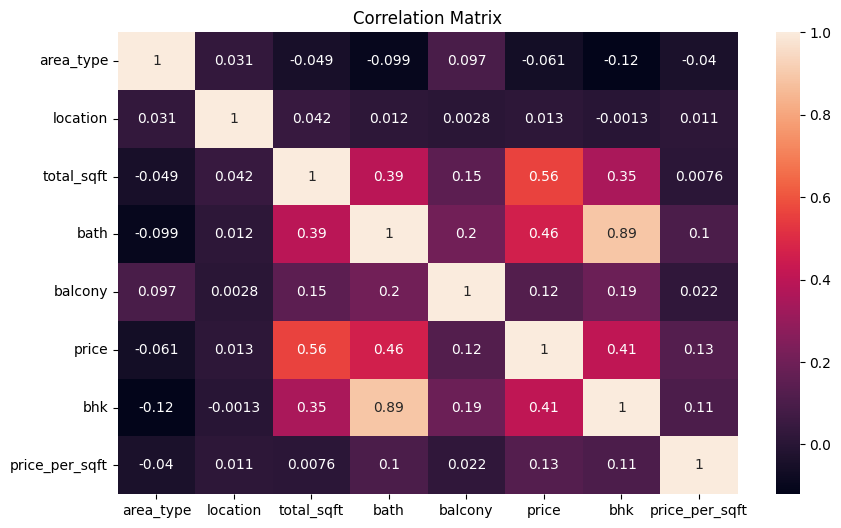

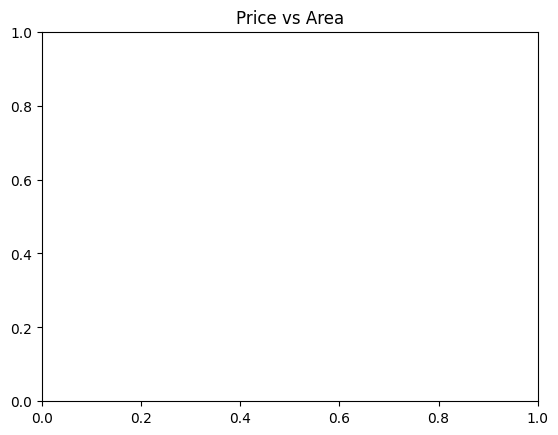

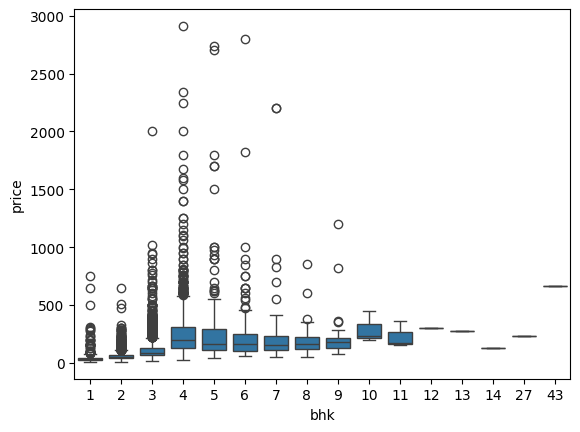

/tmp/ipykernel_158/477654128.py:15: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price'],bins=50)


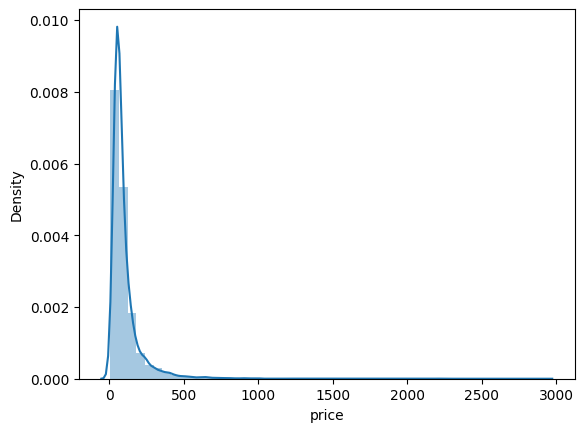

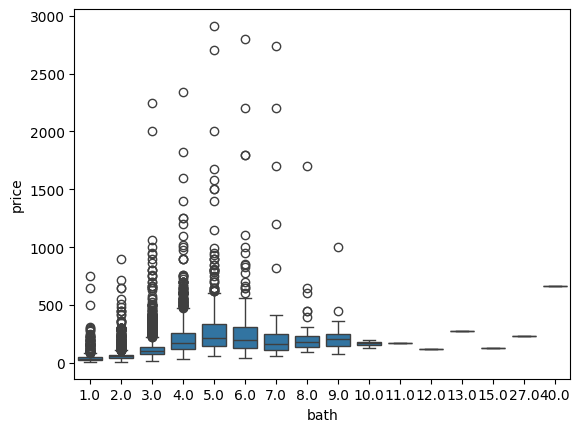

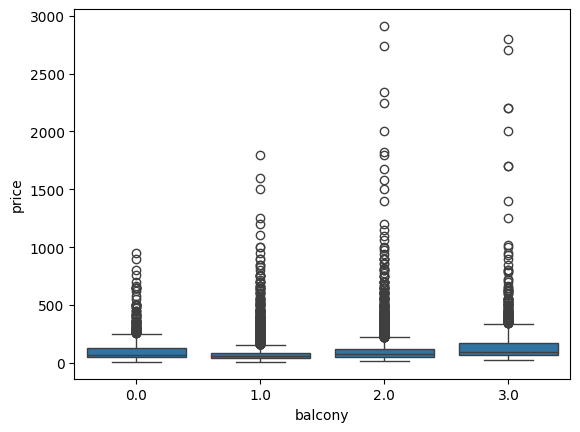

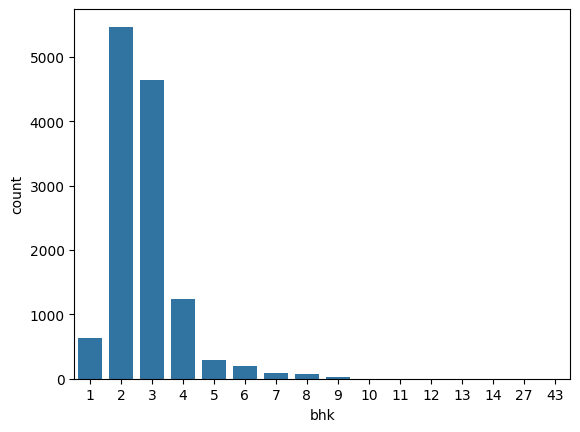

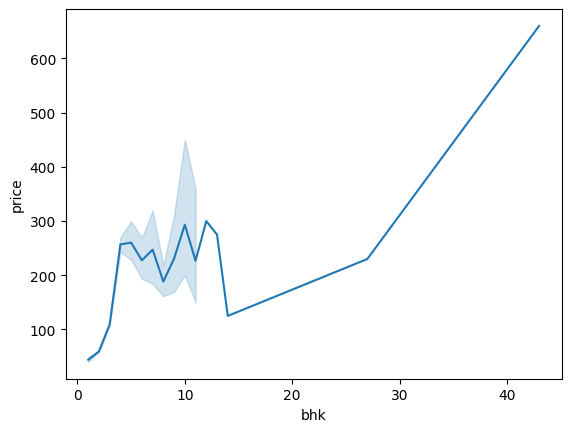

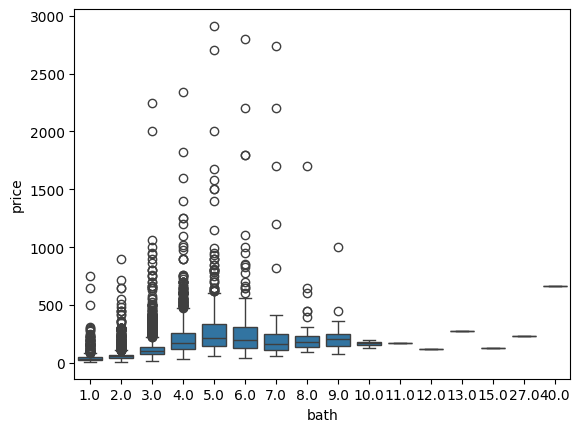

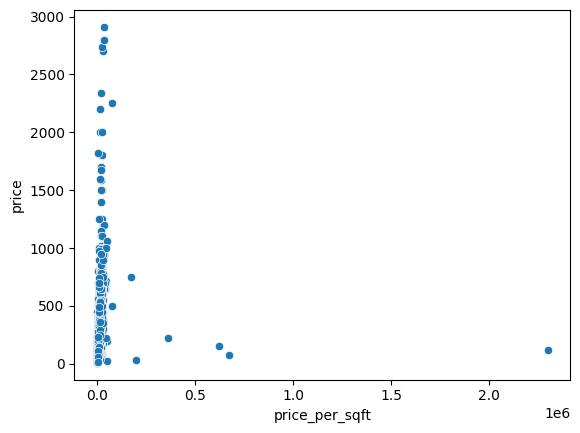

/tmp/ipykernel_158/477654128.py:43: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['total_sqft'], bins=50)


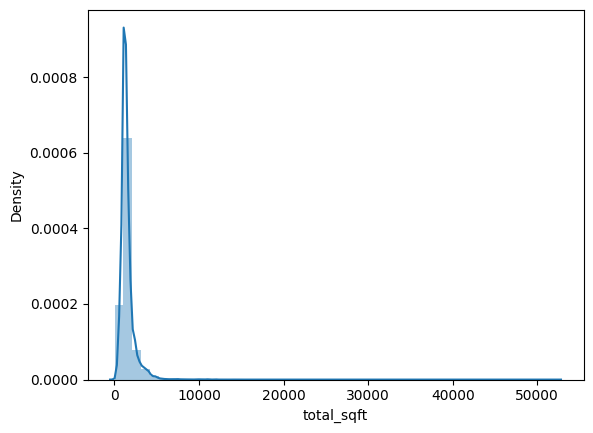

In [18]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

#price vs areasns.scatterplot(x='total_sqft', y='price', data=df)
plt.title("Price vs Area")
plt.show()

#bhk vs price
sns.boxplot(x='bhk', y='price', data=df)
plt.show()

#price distribuction
sns.distplot(df['price'],bins=50)
plt.show()

#bath vs price
sns.boxplot(x='bath', y='price', data=df)
plt.show()

#balcony vs price
sns.boxplot(x='balcony', y='price', data=df)
plt.show()

#bhk count
sns.countplot(x='bhk', data=df)
plt.show()

#bhk vs price trend
sns.lineplot(x='bhk', y='price', data=df)
plt.show()

#bath vs price boxplot
sns.boxplot(x='bath', y='price', data=df)
plt.show()

#price per sqft vs price
sns.scatterplot(x='price_per_sqft', y='price', data=df)
plt.show()

#area distribution
sns.distplot(df['total_sqft'], bins=50)
plt.show()


In [19]:
X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [21]:
dt = DecisionTreeRegressor()

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [22]:
rf = RandomForestRegressor()

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [23]:
def evaluate(y_test, pred):

    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    return rmse, mae, r2

In [24]:
print("Linear Regression:", evaluate(y_test, lr_pred))

print("Decision Tree:", evaluate(y_test, dt_pred))

print("Random Forest:", evaluate(y_test, rf_pred))

Linear Regression: (np.float64(117.20868910964678), 42.21013299473877, 0.36051105539338024)
Decision Tree: (np.float64(37.19413221983307), 4.199782951854775, 0.9356034969079423)
Random Forest: (np.float64(32.722122998340076), 2.94371910023678, 0.9501578957802999)


In [25]:
importance = rf.feature_importances_

features = X.columns

feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

feature_importance.sort_values(by='Importance', ascending=False).head()

,Feature,Importance
2,total_sqft,0.567834
6,price_per_sqft,0.422439
1,location,0.006181
5,bhk,0.001204
3,bath,0.000851
